<div>
Olá, Chau!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-danger">
<b> Comentário geral do revisor v1</b> <a class="tocSkip"></a>
<s>
    
Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. O seu projeto possui alguns pontos bem interessantes, dos quais eu destaco:
    
- Código bem simples e estruturado 
- Conclusões pertinentes em cada análise e etapa de avaliação
    
Entretanto, deixei alguns comentários em alguns trechos que precisam de ajuste. Peço que trabalhe nesses pontos para avançarmos.
    
Qualquer dúvida, pode contar comigo.   
    
    
**Até breve!**
</s>
</div>

<div class="alert alert-block alert-success">
<b> Comentário geral do revisor</b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e fazer os ajustes sugeridos. Essa versão do seu trabalho ficou muito melhor! Espero que as sugestões sejam relevantes para projetos futuros.
    
<br>
Te desejo uma jornada de muito sucesso e aprendizado.
    
<br>   
    
Qualquer dúvida, pode contar comigo.   
    
<br>  
    
**Até breve!**

</div>

### Introdução
1. Importando bibliotecas.
2. Criando caminho para os dados.
3. Leitura dos dados.
4. Manipulação de dados

In [129]:
import pandas as pd
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import math
from scipy.stats import norm
import numpy as np

In [59]:
marketing = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
part = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os dados foram carregados corretamente
- Os valores ausentes foram estudados
    
</div>

In [60]:
marketing.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [61]:
marketing.describe()

,name,regions,start_dt,finish_dt
count,14,14,14,14
unique,14,6,14,14
top,Chinese New Year Promo,APAC,2020-07-04,2020-11-12
freq,1,4,1,1


In [62]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes


In [63]:
marketing.size

56

In [64]:
# Alterando as colunas de datas para permitir realizar futuras ações com as mesmas.

In [65]:
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

In [66]:
users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [67]:
users.describe()

,user_id,first_date,region,device
count,58703,58703,58703,58703
unique,58703,17,4,4
top,3D4C025C176F19C4,2020-12-21,EU,Android
freq,1,6077,43396,26159


In [68]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [69]:
users.duplicated().sum()

0

In [70]:
users.size

234812

In [71]:
# Alterando os tipos de colunas para facilitar futuras ações

In [72]:
users['first_date'] = pd.to_datetime(users['first_date'])

In [73]:
users['device'] = users['device'].astype('category')


In [74]:
events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [75]:
events.describe()

,details
count,60314.000000
mean,23.881219
std,72.228884
min,4.990000
25%,4.990000
50%,4.990000
75%,9.990000
max,499.990000


In [76]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


In [77]:
events.duplicated().sum()

0

In [78]:
events.size

1695044

In [79]:
events['details'].isna().sum()

363447

In [80]:
events.loc[events['event_name'] == 'purchase', 'details'].isna().sum()


0

In [81]:
# Identificamos que os valores ausentes são de eventos antes da compra realizada, então não existe um valor gasto para tal ação, substituiremos os valores para 0, e alteraremos 'event_dt' para datetime.

In [82]:
events['event_dt'] = pd.to_datetime(events['event_dt'])

In [83]:
events['details'] = events['details'].fillna(0)

In [84]:
part.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [85]:
part.describe()

,user_id,group,ab_test
count,14525,14525,14525
unique,13638,2,2
top,8C0361CB080810CA,A,interface_eu_test
freq,2,8214,10850


In [86]:
part.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


In [87]:
part.duplicated().sum()

0

In [88]:
part.size

43575

In [89]:
# Alteração da coluna group  e ab_test para category.

In [90]:
part['group'] = part['group'].astype('category')
part['ab_test'] = part['ab_test'].astype('category')

In [91]:
# Definindo um padrão para os ID's ficarem em caixa alta para não perder informações

In [92]:
users['user_id'] = users['user_id'].str.upper()
events['user_id'] = events['user_id'].str.upper()
part['user_id'] = part['user_id'].str.upper()

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
<s>
    
Aqui você precisa contar a quantidade distinta de usuários em cada etapa. Exemplo:

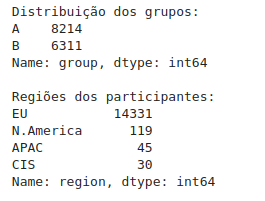

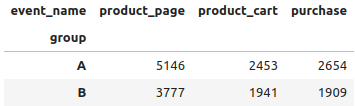

</s>
</div>

 <div class="alert alert-block alert-info">
<b>Segue abaixo o local para verificação da quantidade distinta de usuários em cada etapa.</b> <a class="tocSkip"></a>
</div>

1. [Quantidade distinta de usuários em cada etapa](#visualização-dados)

# Decomposição do projeto.
1. Avaliar se o novo sistema de recomendação teve uma melhoria de mais de 10% nas taxas do funil(Visualiazação de páginas, adicionar item ao carrinho e finalizar compra)

2. Os dados foram coletados corretamente?

3. Público alvo correto?
4. Grupos A e B equilibrados?
5. Há diferenças significativas entre os grupos nas métricas?
6. O efeito é estatisticamente significativo?

# Plano de trabalho
1. Carregar todos os CSVs.
2. Conferir tipos de dados e valores ausentes / duplicidades.
3. Verificar datas.
### Validação do teste A/B.
1. Verificar participantes(Usúarios e Grupos)
2. Tamanho dos grupos.
3. Diferença entre os grupos > 10%
4. 15% dos novos usuários da UE
5. Construção do Funil
6. Teste estatístico
7. Visualizações dos dados.
8. Conclusõoes e recomendações.

In [93]:
# Realizando a montagem dos grupos com filtragem de janela dentro de 14 dias.

In [94]:
participants = part[part['ab_test'] == 'recommender_system_test']
part_users = users.merge(participants[['user_id','group']], on='user_id', how='inner')

In [95]:
users = users.merge(part[['user_id', 'group',]], on='user_id', how='inner')


In [96]:
users_events = events.merge(users[['user_id', 'first_date', 'group','region']],on='user_id',how='inner')
users_events = users_events[users_events['event_dt'] <= users_events['first_date'] + pd.Timedelta(days=14)]

In [97]:
users_events

,user_id,event_dt,event_name,details,first_date,group,region
0,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99,2020-12-07,B,EU
1,96F27A054B191457,2020-12-08 09:43:14,purchase,4.99,2020-12-07,B,EU
2,96F27A054B191457,2020-12-09 00:44:10,purchase,4.99,2020-12-07,B,EU
4,96F27A054B191457,2020-12-07 04:02:41,product_page,0.00,2020-12-07,B,EU
5,96F27A054B191457,2020-12-08 09:43:18,product_page,0.00,2020-12-07,B,EU
...,...,...,...,...,...,...,...
102833,40076B77CFC12421,2020-12-23 03:43:28,login,0.00,2020-12-23,B,EU
102834,40076B77CFC12421,2020-12-24 04:21:53,login,0.00,2020-12-23,B,EU
102835,40076B77CFC12421,2020-12-26 03:50:17,login,0.00,2020-12-23,B,EU
102836,301C602AF78BABAD,2020-12-23 10:39:25,login,0.00,2020-12-23,B,EU


In [98]:
flags = (
    users_events
        .pivot_table(
            index='user_id',
            columns='event_name',
            values='event_dt',
            aggfunc='min'     
        )
        .notna()               
        .astype(int)          
        .reset_index()
)

In [99]:
flags = flags.merge(
    users[['user_id', 'group']],
    on='user_id',
    how='inner'
)

In [100]:
summary = flags.groupby('group').agg(
    users_total=('user_id','nunique'),
    views=('product_page','sum'),
    carts=('product_cart','sum'),
    purchases=('purchase','sum')
).reset_index()

In [101]:
users_by_region = (
    users
    .groupby('region')['user_id']
    .nunique()
    .sort_values(ascending=False)
)

In [102]:
### Contagem dos grupos e quantidade distinta de usuários em cada etapa

In [103]:
### visualização dados

In [104]:
summary

,group,users_total,views,carts,purchases
0,A,7873,5418,2580,2803
1,B,6204,4049,2067,2038


In [105]:
users_by_region

region
EU           13444
N.America      119
APAC            45
CIS             30
Name: user_id, dtype: int64

In [106]:
# Calculando taxas de conversão do funil

In [107]:
summary['rate_views'] = summary['views'] / summary['users_total']
summary['rate_carts'] = summary['carts'] / summary['users_total']
summary['rate_purchases'] = summary['purchases'] / summary['users_total']

In [108]:
# Calculando taxas condicionais do funil

In [109]:
summary['cart_given_view'] = summary['carts'] / summary['views']
summary['purchase_given_cart'] = summary['purchases'] / summary['carts']

In [110]:
summary

,group,users_total,views,carts,purchases,rate_views,rate_carts,rate_purchases,cart_given_view,purchase_given_cart
0,A,7873,5418,2580,2803,0.688175,0.327702,0.356027,0.476190,1.086434
1,B,6204,4049,2067,2038,0.652643,0.333172,0.328498,0.510496,0.985970


In [111]:
flags['no_cart_but_purchase'] = (flags['purchase'] == 1) & (flags['product_cart'] == 0)

flags['no_cart_but_purchase'].sum()

3309

In [112]:
flags.loc[flags['no_cart_but_purchase'], ['user_id']]

,user_id
3,0010A1C096941592
7,0031F1B5E9FBF708
14,004C58ADE7CA8C4A
17,0053DD654C9513D6
19,005E096DBD379BCF
...,...
14492,FF4456FBA59116E3
14498,FF5B24BCE4387F86
14503,FF827554725859E2
14508,FFA72985E689ABBB


In [117]:
# Por termos um valor maior do que 1 em 'purchase_given_cart', conseguimos identificar que existem eventos de 'purchase', sem passar pelo 'cart', o que indica uma falha de rastreamento nos eventos.
# Por se tratar de um valor alto 3309, não podemos avaliar o funil completamente, já que não podemos confiar nos dados de cart > purchase

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

    
Algumas análises estão pendentes em seu projeto. Vou listá-las abaixo em sequência.

</div>

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
<s>
    
Aqui você precisa analisar a distribuição dos dados ao longo dos dias para encontrar um detalhe interessante. Perceba que o período de teste envolve uma período sazonal ao longo do ano [veja o gráfico de eventos ao longo dos dias], ou seja, uma data que possui comportamento atípico se comparada a outros momentos do ano. Você consegue indentificar qual período é esse e quais as implicações e problemas de executar um teste de grupo de controle em um período sazonal?
    
<br>
    
Aqui o ideal é indentificar quando ocorre esse período sazonal e suas implicações. Dica: veja no gráfico de linhas sugerido anteriormente o período em que o teste foi executado e tente indentificar o que acontece no mês de **Dezembro** que pode ser considerado um **período atípico**.
    
Por fim, reflita sobre a seguinte pergunta: o período selecionado para condução do teste de conversão é um **bom período**? Peço que justifique sua escolha. Qual o impacto da **intersecção de usuários** nos resultados do teste?

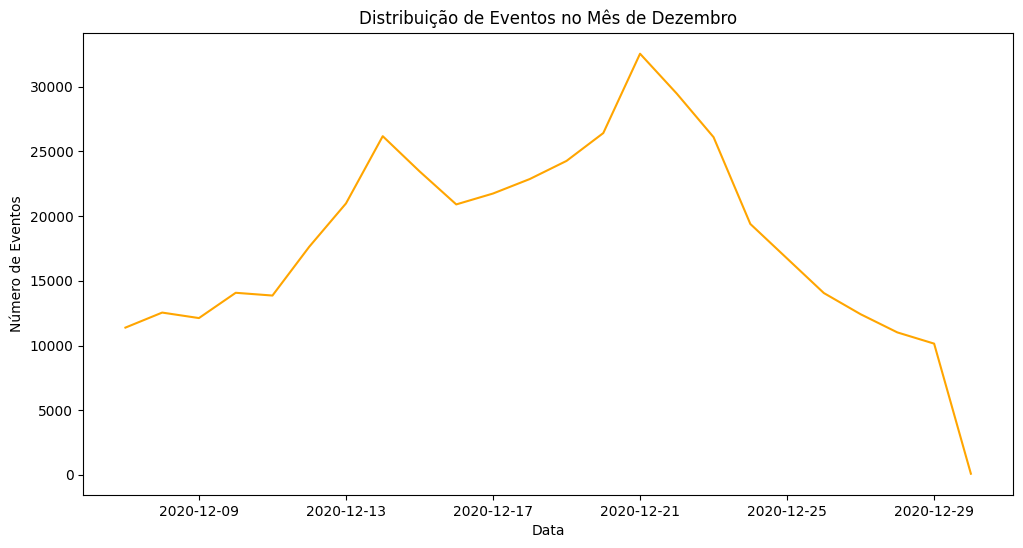
</s>
</div>

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
<s>
    
Segue um exemplo para te ajudar a plotar a distribuição acima:

```python
df['event_day'] = df['event_dt'].dt.date
daily_events = df.groupby('event_day')['user_id'].count().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_events, x='event_day', y='user_id', color='blue')
plt.title('Distribuição de Eventos ao Longo dos Dias (Período de Teste)')
plt.xlabel('Data')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
```
</s>
</div>

In [114]:
# Verificando os eventos ao longo dos dias

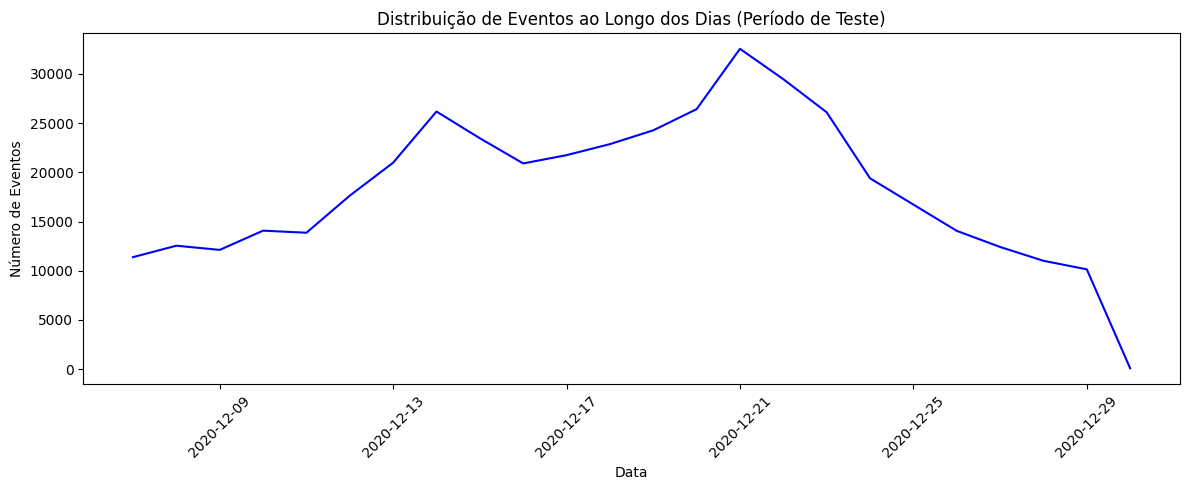

In [115]:
events['event_day'] = events['event_dt'].dt.date
daily_events = events.groupby('event_day')['user_id'].count().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_events, x='event_day', y='user_id', color='blue')
plt.title('Distribuição de Eventos ao Longo dos Dias (Período de Teste)')
plt.xlabel('Data')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [116]:
# Podemos análisar que ao final de dezembro, por termos feriados como Natal e Ano Novo, a frequencia de eventos acaba caindo drasticamente, o que sujere não ser uma boa época para realizar o teste.

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
<s>
    
*Qual o percentual de usuários está em ambos os grupos?* *O que isso quer dizer a respeito da robustez do teste de hipótese que está sendo conduzido?* 
    
Isso impacta o resultado de alguma forma? É preciso que você reflita sobre essa característica para chegar a uma conclusão final do projeto.
</s>
</div>

<div class="alert alert-block alert-danger">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
<s>
    
Aqui você precisa calcular a taxa de conversão por grupo também. Sugestão: você pode plotar essa distribuição por grupo e evento, conforme exemplo abaixo.

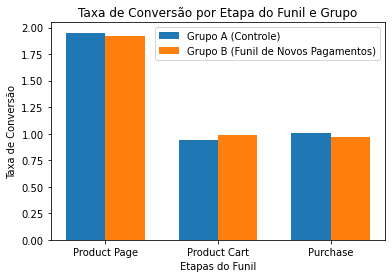
</s>
</div>

In [123]:
# Calculando o percentual de usuários em ambos os grupos

In [122]:
users_A = set(users_events[users_events['group'] == 'A']['user_id'])
users_B = set(users_events[users_events['group'] == 'B']['user_id'])

# interseção
users_overlap = users_A.intersection(users_B)

# percentuais
overlap_pct_A = len(users_overlap) / len(users_A) * 100
overlap_pct_B = len(users_overlap) / len(users_B) * 100

print(f"Quantidade de usuários em ambos os grupos: {len(users_overlap)}")
print(f"% do grupo A no outro grupo: {overlap_pct_A:.2f}%")
print(f"% do grupo B no outro grupo: {overlap_pct_B:.2f}%")

Quantidade de usuários em ambos os grupos: 441
% do grupo A no outro grupo: 5.60%
% do grupo B no outro grupo: 7.11%


In [ ]:
# Foram encontrados cerca de 441 usuários em ambos os grupos, o que pode prejudicar a análise, mas insuficiente para invalidar o teste. 

In [132]:
# Gerando gráfico para acompanar taxa de conversão por etapa do funil

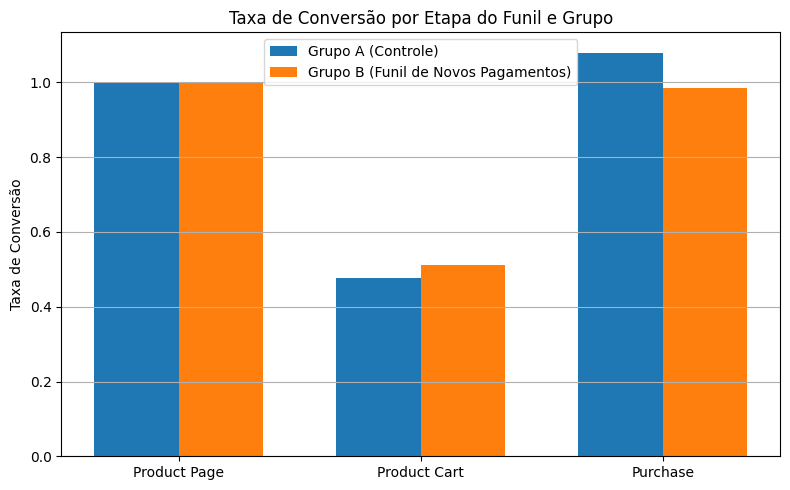

In [131]:
stages = ['Product Page', 'Product Cart', 'Purchase']

group_A = [
    1.0,
    float(conversion.loc['A', 'cart_given_view']),
    float(conversion.loc['A', 'purchase_given_cart'])
]

group_B = [
    1.0,
    float(conversion.loc['B', 'cart_given_view']),
    float(conversion.loc['B', 'purchase_given_cart'])
]

x = np.arange(len(stages))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, group_A, width, label='Grupo A (Controle)')
plt.bar(x + width/2, group_B, width, label='Grupo B (Funil de Novos Pagamentos)')

plt.xticks(x, stages)
plt.ylabel('Taxa de Conversão')
plt.title('Taxa de Conversão por Etapa do Funil e Grupo')
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

### Comparando as distribuições para verificar a igualdade entre amostras

In [52]:
events_per_user = (
    events.groupby(['user_id'])
          .size()
          .reset_index(name='event_count')
)
events_per_user = events_per_user.merge(
    participants[['user_id', 'group']],
    on='user_id',
    how='inner'
)

In [53]:
A = events_per_user[events_per_user['group'] == 'A']['event_count']
B = events_per_user[events_per_user['group'] == 'B']['event_count']

In [54]:
stat, p = mannwhitneyu(A, B, alternative='two-sided')
print("U-statistic:", stat)
print("p-value:", p)

U-statistic: 1507455.0
p-value: 3.625922279604957e-17


In [55]:
# O valor de P é extremamente pequeno, a distribuição do número de eventos por usuário são significativamente diferentes.

In [56]:
summary

,group,users_total,views,carts,purchases,rate_views,rate_carts,rate_purchases,cart_given_view,purchase_given_cart
0,A,7873,5418,2580,2803,0.688175,0.327702,0.356027,0.476190,1.086434
1,B,6204,4049,2067,2038,0.652643,0.333172,0.328498,0.510496,0.985970


In [75]:
conv_a = summary.loc[summary['group']=="A", 'purchases'].iloc[0].item()
conv_b = summary.loc[summary['group']=="B", 'purchases'].iloc[0].item()

In [74]:
size_a = summary.loc[summary['group']=="A", 'users_total'].iloc[0].item()
size_b = summary.loc[summary['group']=="B", 'users_total'].iloc[0].item()

In [76]:
p1 = conv_a / size_a
p2 = conv_b / size_b

In [77]:
p_comb = ((conv_a + conv_b) / (size_a + size_b))

In [78]:
se = math.sqrt(p_comb * (1 - p_comb) * ((1/size_a) + (1/size_b)))

In [82]:
z_stat = (p2 - p1) / se
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print("Z-score:", z_stat)
print("P-value:", p_value)

Z-score: -3.4138537504619486
P-value: 0.0006405094785726373


In [83]:
# Existe uma diferença estatisticamente significativa entre os grupos A e B.

In [84]:
summary

,group,users_total,views,carts,purchases,rate_views,rate_carts,rate_purchases,cart_given_view,purchase_given_cart
0,A,7873,5418,2580,2803,0.688175,0.327702,0.356027,0.476190,1.086434
1,B,6204,4049,2067,2038,0.652643,0.333172,0.328498,0.510496,0.985970


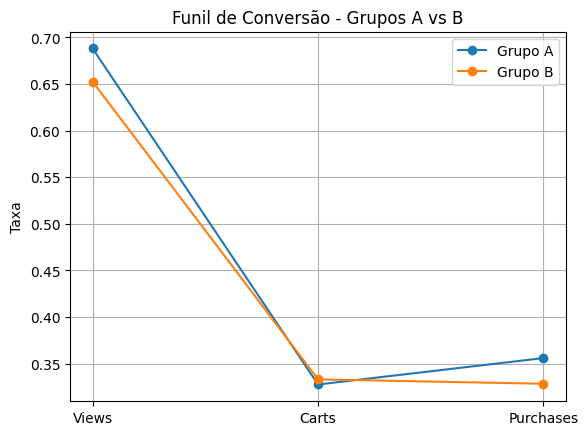

In [86]:
labels = ['Views', 'Carts', 'Purchases']
x = range(len(labels))

A = summary[summary['group'] == 'A'][['rate_views','rate_carts','rate_purchases']].iloc[0]
B = summary[summary['group'] == 'B'][['rate_views','rate_carts','rate_purchases']].iloc[0]

plt.plot(x, A, marker='o', label='Grupo A')
plt.plot(x, B, marker='o', label='Grupo B')

plt.xticks(x, labels)
plt.ylabel("Taxa")
plt.title("Funil de Conversão - Grupos A vs B")
plt.legend()
plt.grid(True)
plt.show()

In [87]:
#Conseguimos identificar que o novo sistema não trouxe uma melhora de 10% conforme informado, na verdade tivemos uma queda em Visualizações e compras em comparação ao grupo A.

# Conclusões
### Foi identificado um defice de informações muito grande entre o número de compras e o evento de colocar a compra no carrinho, mais de 3000 casos, o que leva a mais de 1/3 dos dados comprometidos.
### Apesar da falta de informações, identificamos que não existiu uma melhora significativa no novo sistema de recomendação.
### Os grupos A e B apresentam taxas de conversão muito próximas em todas as etapas do funil. Os testes indicam que as diferenças observadas são estatisticamente significativas, mas o efeito é pequeno.
### A presença de usuários em ambos os grupos e o prazo escolhido para o teste(Dezembro) reduz a robustez do teste, dessa forma não é possível afirmar que o novo sistema trouxe uma melhoria relevante no desempenho